# Análise exploratória da série temporal de tráfego do PTT/IX

Este notebook foi adaptado para:

- trabalhar **apenas com o tráfego total** (`entrada + saída`);
- realizar as análises **somente após o filtro de completude anual**;
- expressar os resultados em **Gbps**;
- gerar resumos anuais em Gbps;
- plotar a série temporal total com **média diária** e **intervalo de confiança de 95%**;
- analisar o comportamento por **dia da semana**;
- comparar **dias úteis** com **fim de semana**.

## 1. Importação de bibliotecas

In [101]:
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path
import calendar

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Caminhos dos arquivos

Ajuste esta célula conforme a estrutura do seu projeto.

Se o notebook estiver em `monograph/notebooks` e a pasta `data` estiver em `monograph/data`, então `Path.cwd().parent` costuma ser suficiente.

In [102]:
base_dir = Path.cwd().parent  # ajuste se necessário

arquivo_xml = base_dir / "data" / "raw" / "ptt.xml"
saida_dir = base_dir / "data" / "processed"

arquivo_serie_csv = saida_dir / "serie_temporal_filtrada_gbps.csv"
arquivo_resumo_csv = saida_dir / "resumo_anual_filtrado_gbps.csv"
arquivo_weekday_csv = saida_dir / "resumo_weekday_gbps.csv"
arquivo_weekend_csv = saida_dir / "comparacao_weekend_gbps.csv"

saida_dir.mkdir(parents=True, exist_ok=True)

print("Base dir:", base_dir)
print("XML:", arquivo_xml)
print("Existe?", arquivo_xml.exists())
print("Saída:", saida_dir)

Base dir: /Users/cristiane/git/mba-ai-usp/monograph
XML: /Users/cristiane/git/mba-ai-usp/monograph/data/raw/ptt.xml
Existe? True
Saída: /Users/cristiane/git/mba-ai-usp/monograph/data/processed


## 3. Leitura do arquivo XML

In [103]:
tree = ET.parse(arquivo_xml)
root = tree.getroot()

step = int(root.find("step").text)
lastupdate = int(root.find("lastupdate").text)
rows = root.find("rra/database").findall("row")

print("step (segundos):", step)
print("lastupdate:", lastupdate)
print("número de linhas:", len(rows))

step (segundos): 300
lastupdate: 1768334849
número de linhas: 2100154


## 4. Funções auxiliares

In [104]:
def parse_valor(texto):
    if texto is None or texto == "NaN":
        return None
    return float(texto)

def medicoes_esperadas_no_ano(ano, passo_segundos=300):
    dias = 366 if calendar.isleap(ano) else 365
    return (24 * 60 * 60 // passo_segundos) * dias

## 5. Reconstrução da série temporal

Cada linha do XML possui dois valores (`v`), correspondentes aos fluxos de entrada e saída.

Neste notebook, a variável principal de análise será:

`total_bps = entrada + saída`

In [ ]:
n = len(rows)
start_time = lastupdate - (n * step)

serie = []

for i, row in enumerate(rows):
    timestamp = start_time + i * step
    datahora = datetime.fromtimestamp(timestamp)

    vals = row.findall("v")

    v0 = parse_valor(vals[0].text) if len(vals) > 0 else None
    v1 = parse_valor(vals[1].text) if len(vals) > 1 else None

    total = None if (v0 is None or v1 is None) else (v0 + v1)

    serie.append((datahora, total))

df = pd.DataFrame(serie, columns=["datahora", "total_bps"])
df["datahora"] = pd.to_datetime(df["datahora"])
df["year"] = df["datahora"].dt.year

df.head()

## 6. Verificação inicial

In [106]:
print(df.head())
print()
print(df.info())
print()
print("Período coberto:")
print(df["datahora"].min(), "até", df["datahora"].max())
print()
print("NaN em total_bps:", df["total_bps"].isna().sum())

             datahora  total_bps  year
0 2006-01-26 13:17:29        NaN  2006
1 2006-01-26 13:22:29        NaN  2006
2 2006-01-26 13:27:29        NaN  2006
3 2006-01-26 13:32:29        NaN  2006
4 2006-01-26 13:37:29        NaN  2006

<class 'pandas.DataFrame'>
RangeIndex: 2100154 entries, 0 to 2100153
Data columns (total 3 columns):
 #   Column     Dtype         
---  ------     -----         
 0   datahora   datetime64[us]
 1   total_bps  float64       
 2   year       int32         
dtypes: datetime64[us](1), float64(1), int32(1)
memory usage: 40.1 MB
None

Período coberto:
2006-01-26 13:17:29 até 2026-01-13 17:02:29

NaN em total_bps: 217539


## 7. Resumo de completude anual

A completude anual é calculada com base em `total_bps`, comparando o número esperado de medições com o número de valores ausentes.

In [ ]:
resumo_completude = df.groupby("year").agg(
    total_linhas=("total_bps", "size"),
    n_na_total=("total_bps", lambda x: x.isna().sum())
)

resumo_completude["esperado"] = resumo_completude.index.map(medicoes_esperadas_no_ano)
resumo_completude["completude"] = 1 - (
    resumo_completude["n_na_total"] / resumo_completude["esperado"]
)

resumo_completude["completude"] = resumo_completude["completude"].round(3)

resumo_completude

### Interpretação

A filtragem por completude é importante para evitar que anos muito incompletos distorçam as análises de tendência e os resumos anuais.

## 8. Filtragem por completude

In [108]:
anos_validos = resumo_completude.loc[resumo_completude["completude"] > 0.95].index

df_filtrado = df[df["year"].isin(anos_validos)].copy()

print("Anos válidos:", list(anos_validos))
print("Dimensão da base filtrada:", df_filtrado.shape)

Anos válidos: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Dimensão da base filtrada: (1897273, 3)


## 9. Conversão para Gbps

A partir deste ponto, todas as análises são feitas sobre os dados filtrados e expressas em **Gbps**.

In [ ]:
df_filtrado["total_gbps"] = df_filtrado["total_bps"] / 1e9
df_filtrado.head()

## 10. Resumo anual apenas dos dados filtrados

O resumo abaixo é calculado **somente após o filtro de completude** e usa exclusivamente o tráfego total.

In [ ]:
resumo = df_filtrado.groupby("year").agg(
    total_linhas=("total_gbps", "size"),
    media_total_gbps=("total_gbps", "mean"),
    mediana_total_gbps=("total_gbps", "median"),
    min_total_gbps=("total_gbps", "min"),
    max_total_gbps=("total_gbps", "max")
)

cols_gbps = ["media_total_gbps", "mediana_total_gbps", "min_total_gbps", "max_total_gbps"]
resumo[cols_gbps] = resumo[cols_gbps].round(3)

resumo

## 11. Salvando os CSVs principais

In [111]:
df_filtrado.to_csv(arquivo_serie_csv, index=False)
resumo.to_csv(arquivo_resumo_csv)

print("Série filtrada salva em:", arquivo_serie_csv)
print("Resumo anual filtrado salvo em:", arquivo_resumo_csv)

Série filtrada salva em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/serie_temporal_filtrada_gbps.csv
Resumo anual filtrado salvo em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/resumo_anual_filtrado_gbps.csv


## 12. Série temporal total com média diária e intervalo de confiança

Como a série original tem resolução de 5 minutos, é útil agregá-la por dia.

Para cada dia, serão calculados:

- média diária do tráfego total em Gbps;
- desvio padrão;
- número de observações;
- intervalo de confiança aproximado de 95%.

In [ ]:
df_diario = df_filtrado.copy()
df_diario["data"] = df_diario["datahora"].dt.floor("D")

media_diaria = (
    df_diario.groupby("data")["total_gbps"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

media_diaria["ci_lower"] = media_diaria["mean"] - 1.96 * (media_diaria["std"] / np.sqrt(media_diaria["count"]))
media_diaria["ci_upper"] = media_diaria["mean"] + 1.96 * (media_diaria["std"] / np.sqrt(media_diaria["count"]))

media_diaria = media_diaria.rename(columns={
    "mean": "media_gbps",
    "std": "desvio_gbps",
    "count": "n_obs"
})

media_diaria.head()

## 13. Plot da série temporal total: média diária + IC 95%

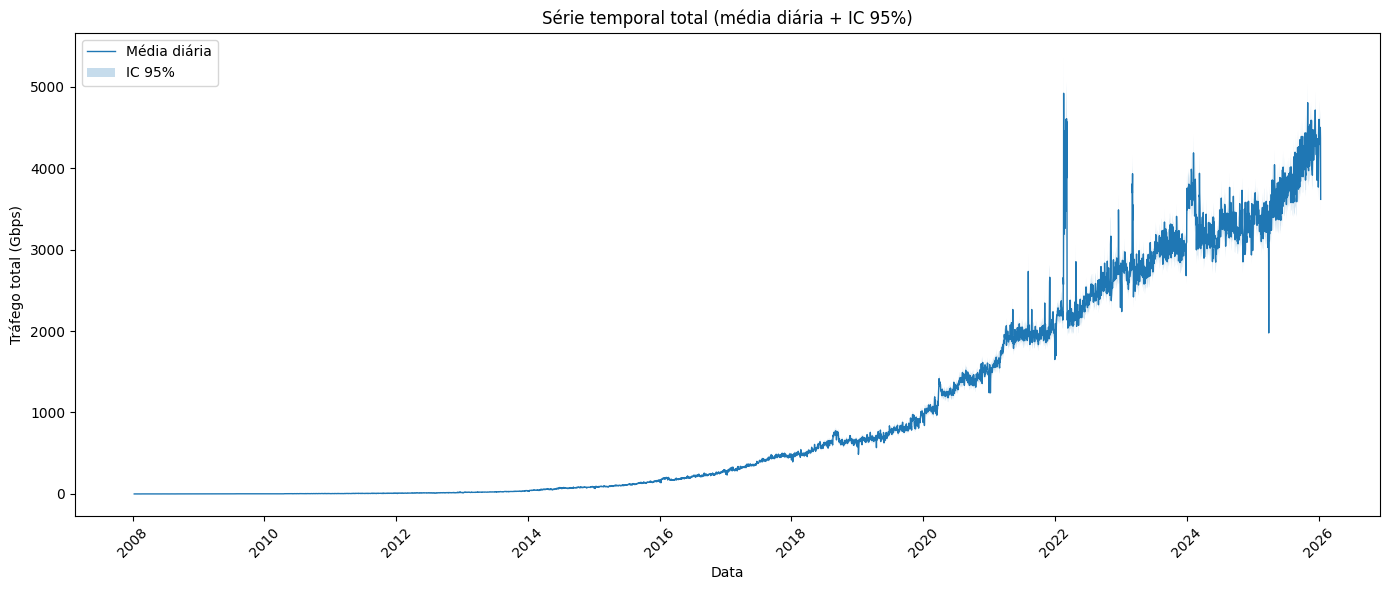

In [96]:
plt.figure(figsize=(14, 6))

plt.plot(
    media_diaria["data"],
    media_diaria["media_gbps"],
    label="Média diária",
    linewidth=1
)

plt.fill_between(
    media_diaria["data"],
    media_diaria["ci_lower"],
    media_diaria["ci_upper"],
    alpha=0.25,
    label="IC 95%"
)

plt.xlabel("Data")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Série temporal total (média diária + IC 95%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação

O uso da média diária reduz o ruído de curtíssimo prazo e facilita a visualização da tendência de longo prazo.

O intervalo de confiança de 95% resume a variabilidade intra-dia:

- faixas mais estreitas sugerem maior estabilidade;
- faixas mais largas sugerem maior dispersão das medições ao longo do dia.

## 14. Média diária suavizada (opcional)

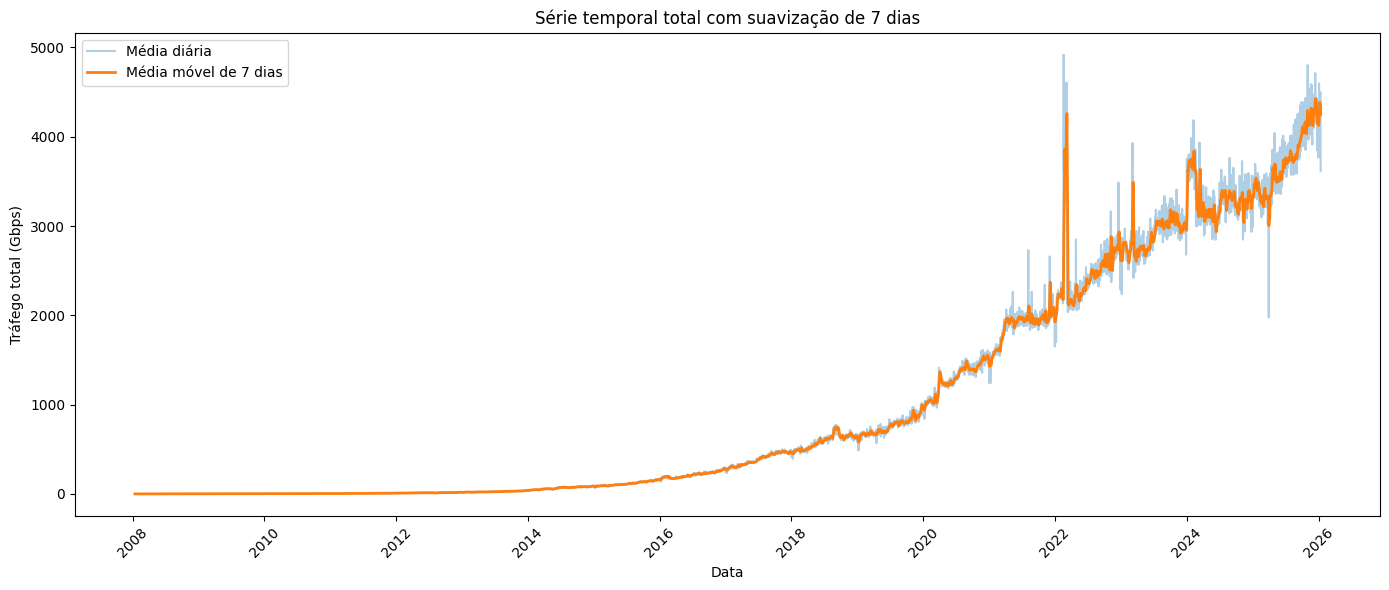

In [97]:
media_diaria["media_movel_7d"] = media_diaria["media_gbps"].rolling(7).mean()

plt.figure(figsize=(14, 6))

plt.plot(
    media_diaria["data"],
    media_diaria["media_gbps"],
    alpha=0.35,
    label="Média diária"
)

plt.plot(
    media_diaria["data"],
    media_diaria["media_movel_7d"],
    linewidth=2,
    label="Média móvel de 7 dias"
)

plt.xlabel("Data")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Série temporal total com suavização de 7 dias")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretação

A média móvel de 7 dias ajuda a destacar a tendência geral da série, reduzindo oscilações diárias.

## 15. Evolução intra-anual com média diária em Gbps

In [98]:
df_plot = df_filtrado.copy()
df_plot["dia_ano"] = df_plot["datahora"].dt.dayofyear

media_intra_anual = (
    df_plot.groupby(["year", "dia_ano"])["total_gbps"]
    .mean()
    .reset_index()
)

media_intra_anual.head()

,year,dia_ano,total_gbps
0,2008,1,NaN
1,2008,2,NaN
2,2008,3,NaN
3,2008,4,NaN
4,2008,5,NaN


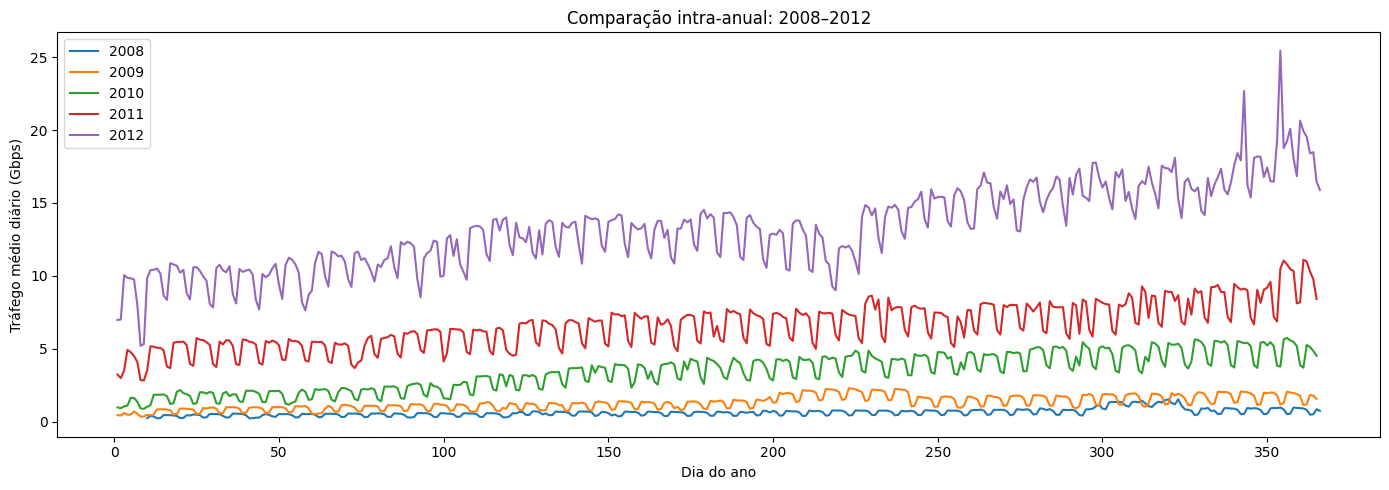

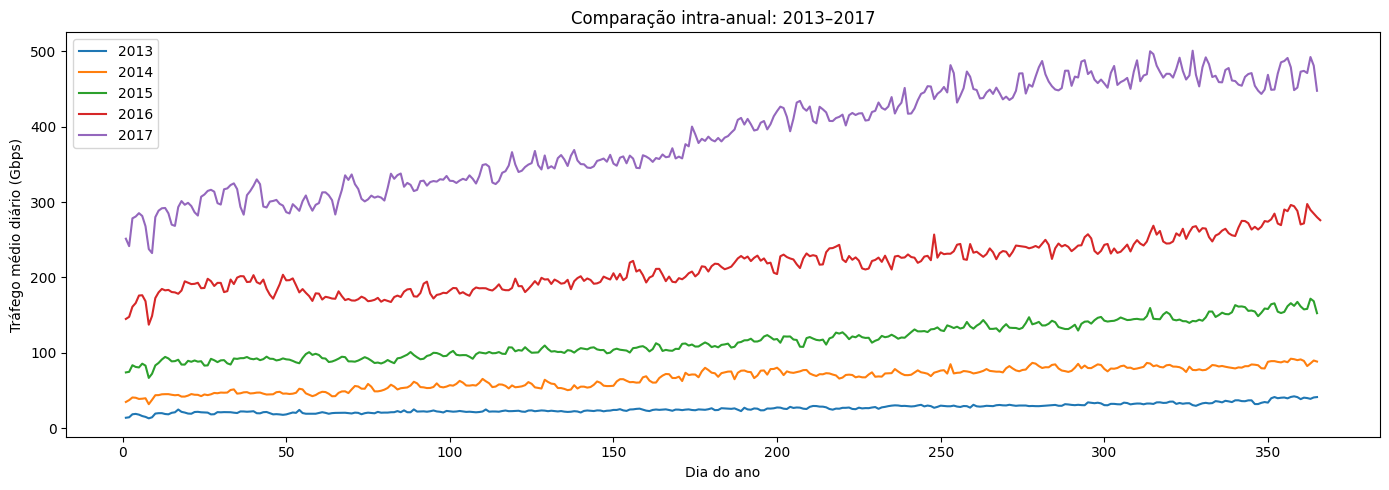

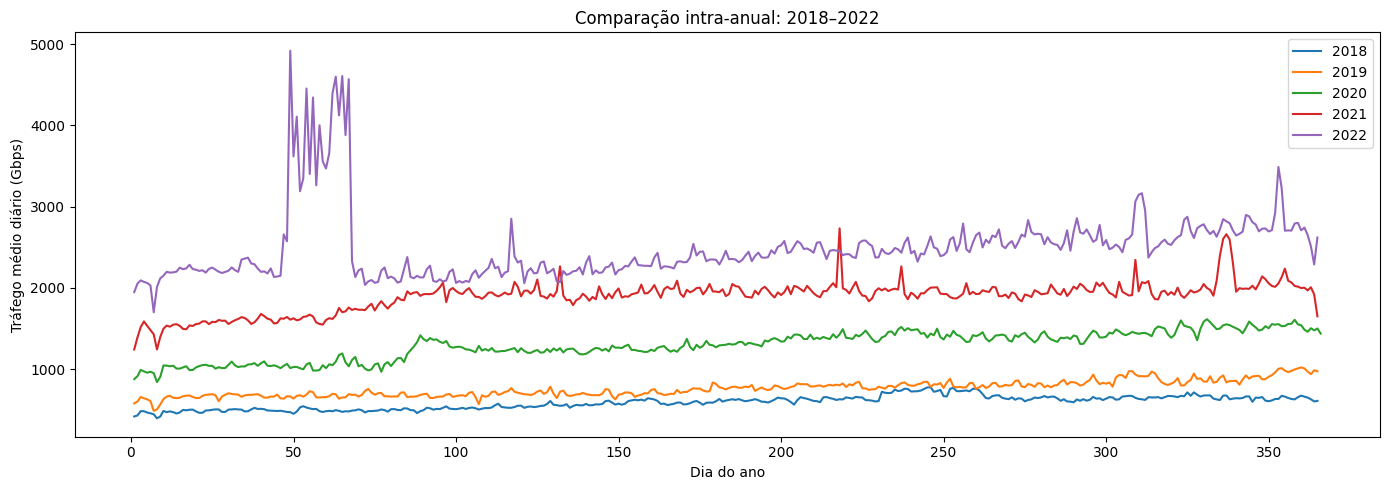

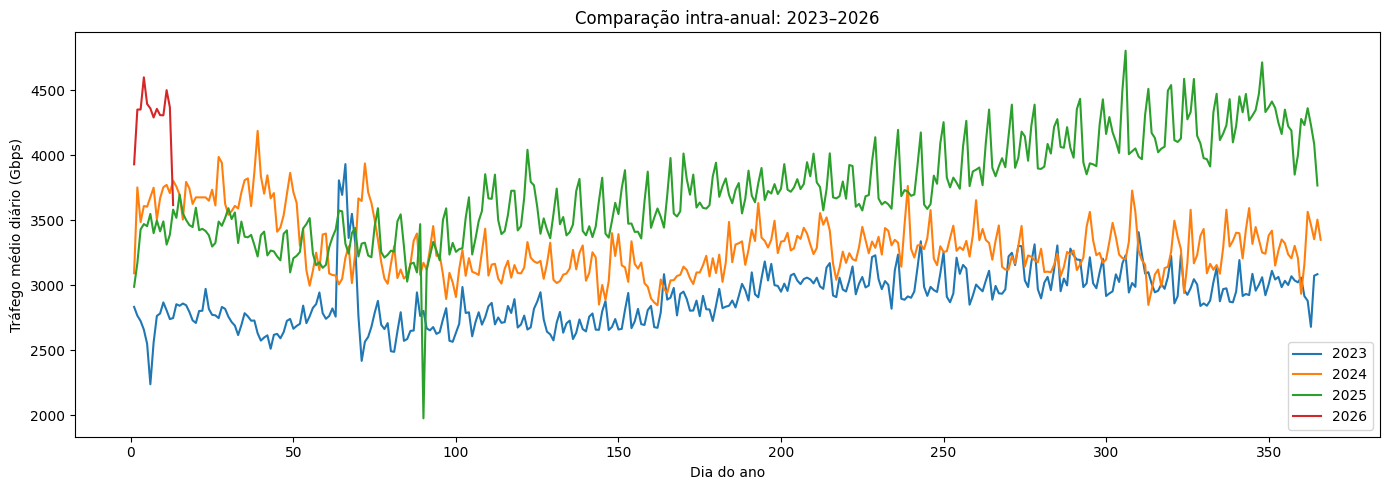

In [112]:
anos = sorted(media_intra_anual["year"].unique())
blocos = [anos[i:i+5] for i in range(0, len(anos), 5)]

for bloco in blocos:
    plt.figure(figsize=(14, 5))
    for ano in bloco:
        grupo = media_intra_anual[media_intra_anual["year"] == ano]
        plt.plot(grupo["dia_ano"], grupo["total_gbps"], label=str(ano))
    plt.xlabel("Dia do ano")
    plt.ylabel("Tráfego médio diário (Gbps)")
    plt.title(f"Comparação intra-anual: {bloco[0]}–{bloco[-1]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Interpretação

Esses gráficos permitem observar se há crescimento dentro do próprio ano, além de possíveis padrões sazonais ou mudanças de regime entre períodos.

## 16. Análise por dia da semana

Agora a análise passa a considerar o comportamento do tráfego total ao longo da semana, usando apenas os dados filtrados.

In [ ]:
df_filtrado["weekday"] = df_filtrado["datahora"].dt.weekday

mapa_dias = {
    0: "Seg",
    1: "Ter",
    2: "Qua",
    3: "Qui",
    4: "Sex",
    5: "Sáb",
    6: "Dom"
}

resumo_weekday_total = (
    df_filtrado.groupby("weekday")["total_gbps"]
    .mean()
    .reset_index(name="media_total_gbps")
)

resumo_weekday_total["dia"] = resumo_weekday_total["weekday"].map(mapa_dias)
resumo_weekday_total["media_total_gbps"] = resumo_weekday_total["media_total_gbps"].round(3)

resumo_weekday_total

### Observação metodológica

A média agregada de todos os anos pode ser enviesada, porque os anos mais recentes têm nível de tráfego muito maior que os anos antigos. Por isso, além do resumo geral, também é útil comparar o padrão semanal por blocos temporais.

## 17. Padrão semanal por blocos de anos com média diária

In [ ]:
for bloco in [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]:
    df_temp = df_filtrado[
        (df_filtrado["year"] >= bloco[0]) &
        (df_filtrado["year"] <= bloco[1])
    ]

    media = df_temp.groupby("weekday")["total_gbps"].mean().reset_index(name="media_total_gbps")
    media["dia"] = media["weekday"].map(mapa_dias)
    media["media_total_gbps"] = media["media_total_gbps"].round(3)

    print(f"\nPeríodo {bloco}:")
    print(media[["weekday", "dia", "media_total_gbps"]])

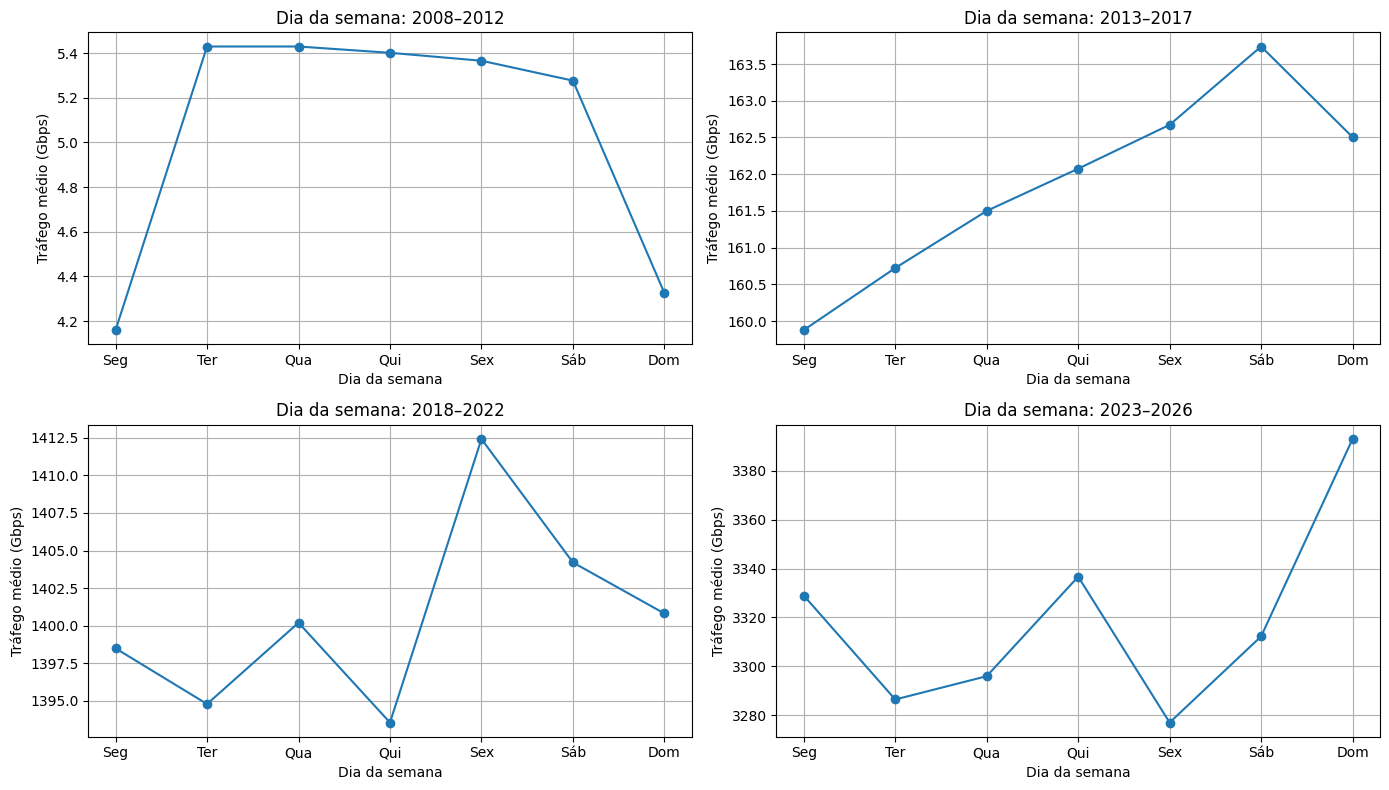

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

periodos = [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]

for ax, bloco in zip(axes, periodos):
    df_temp = df_filtrado[
        (df_filtrado["year"] >= bloco[0]) &
        (df_filtrado["year"] <= bloco[1])
    ]

    media = df_temp.groupby("weekday")["total_gbps"].mean().reset_index(name="media_total_gbps")

    ax.plot(media["weekday"], media["media_total_gbps"], marker="o")
    ax.set_xticks(range(7))
    ax.set_xticklabels([mapa_dias[i] for i in range(7)])
    ax.set_title(f"Dia da semana: {bloco[0]}–{bloco[1]}")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Tráfego médio (Gbps)")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Interpretação

A análise por dia da semana permite verificar se o tráfego é maior em dias úteis ou em fins de semana, além de identificar mudanças de comportamento ao longo do tempo.

Em estudos anteriores deste conjunto de dados, observou-se uma transição de um padrão mais associado a dias úteis para um padrão mais uniforme e, nos anos mais recentes, com domingo relativamente mais forte.

## 19. Comparação entre dias úteis e fim de semana com média diária

Nesta etapa, a semana é resumida em dois grupos:

- **dias úteis**: segunda a sexta;
- **fim de semana**: sábado e domingo.

Interpretação

Essa razão resume o padrão semanal em uma única métrica:

- valores **abaixo de 1** indicam maior tráfego em dias úteis;
- valores **próximos de 1** indicam uniformização do padrão semanal;
- valores **acima de 1** sugerem maior intensidade relativa de tráfego no fim de semana.

Essa análise é útil para detectar mudanças estruturais no perfil de uso da rede.

In [ ]:
df_filtrado["is_weekend"] = df_filtrado["weekday"] >= 5

comparacao_weekend = (
    df_filtrado.groupby(["year", "is_weekend"])["total_gbps"]
    .mean()
    .reset_index()
)

comparacao_weekend["grupo"] = comparacao_weekend["is_weekend"].map({
    False: "dias_uteis",
    True: "fim_de_semana"
})

comparacao_weekend_pivot = comparacao_weekend.pivot(
    index="year",
    columns="grupo",
    values="total_gbps"
)

comparacao_weekend_pivot["razao_fim_semana_sobre_uteis"] = (
    comparacao_weekend_pivot["fim_de_semana"] /
    comparacao_weekend_pivot["dias_uteis"]
)

comparacao_weekend_pivot = comparacao_weekend_pivot.round(3)

comparacao_weekend_pivot

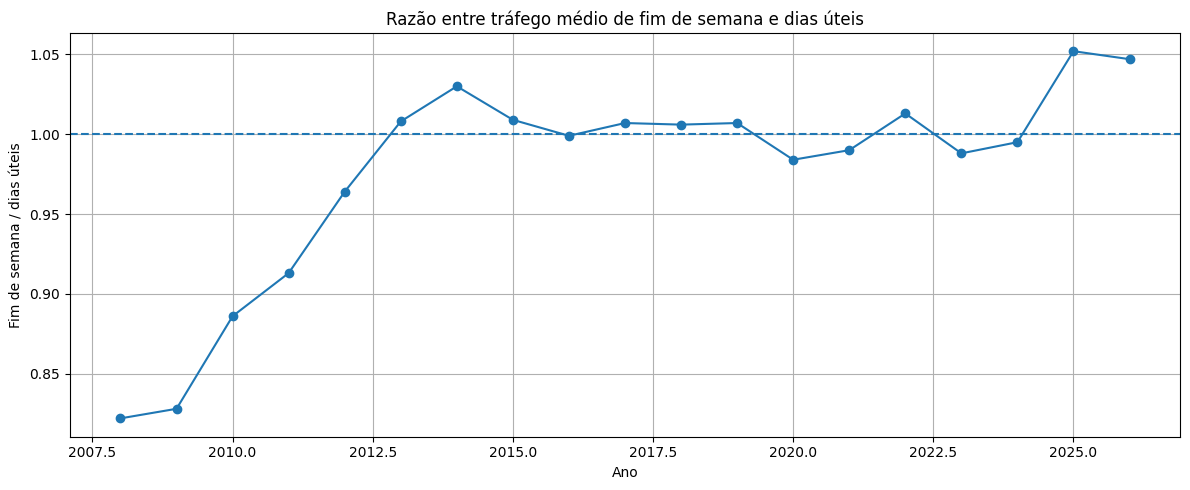

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    comparacao_weekend_pivot.index,
    comparacao_weekend_pivot["razao_fim_semana_sobre_uteis"],
    marker="o"
)
plt.axhline(1.0, linestyle="--")
plt.xlabel("Ano")
plt.ylabel("Fim de semana / dias úteis")
plt.title("Razão entre tráfego médio de fim de semana e dias úteis")
plt.grid(True)
plt.tight_layout()
plt.show()

## 21. Salvando os resumos de weekday e fim de semana

In [ ]:
resumo_weekday_total.to_csv(arquivo_weekday_csv, index=False)
comparacao_weekend_pivot.to_csv(arquivo_weekend_csv)

print("Resumo por dia da semana salvo em:", arquivo_weekday_csv)
print("Comparação dias úteis vs fim de semana salva em:", arquivo_weekend_csv)

Resumo por dia da semana salvo em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/resumo_weekday_gbps.csv
Comparação dias úteis vs fim de semana salva em: /Users/cristiane/git/mba-ai-usp/monograph/data/processed/comparacao_weekend_gbps.csv


# Picos de tráfego

## 22. Análise complementar de PICOS de tráfego

Além das médias diárias, esta seção analisa os **picos de tráfego**. A ideia é complementar a visão do comportamento típico da rede com uma visão dos momentos de maior demanda.

Nesta etapa, o **pico diário** é definido como o **valor máximo diário** de `total_gbps`. Também é calculado o **percentil 95 diário**, útil como medida robusta de alta utilização.

In [ ]:
picos_diarios = (
    df_picos.groupby("data")["total_gbps"]
    .agg(
        pico_max_gbps="max",
        pico_p95_gbps=lambda x: x.quantile(0.95),
        media_gbps="mean",
        desvio_gbps="std",
        n_obs="count"
    )
    .reset_index()
)

# remover dias sem observação (segurança extra)
picos_diarios = picos_diarios[picos_diarios["n_obs"] > 0].copy()

# features
picos_diarios["ano"] = picos_diarios["data"].dt.year
picos_diarios["weekday"] = picos_diarios["data"].dt.weekday
picos_diarios["is_weekend"] = picos_diarios["weekday"] >= 5
picos_diarios["dia_ano"] = picos_diarios["data"].dt.dayofyear
picos_diarios["fator_pico_sobre_media"] = (
    picos_diarios["pico_max_gbps"] / picos_diarios["media_gbps"]
)

## 23. Resumo anual dos picos

O resumo abaixo permite comparar a evolução dos níveis máximos de utilização da rede ao longo dos anos.

In [ ]:
resumo_picos = (
    picos_diarios.groupby("ano")
    .agg(
        media_pico_maximo_gbps=("pico_max_gbps", "mean"),
        mediana_pico_maximo_gbps=("pico_max_gbps", "median"),
        percentil_95_picos_maximos_gbps=("pico_max_gbps", lambda x: x.quantile(0.95)),
        media_percentil_95_diario_gbps=("pico_p95_gbps", "mean"),
        media_fator_pico_sobre_media=("fator_pico_sobre_media", "mean")
    )
    .round(3)
)



In [ ]:
resumo_picos["taxa_crescimento_anual_pico"] = (
    resumo_picos["media_pico_maximo_gbps"].pct_change()
)

resumo_picos["taxa_crescimento_anual_fator"] = (
    resumo_picos["media_fator_pico_sobre_media"].pct_change()
    
).round(3)

resumo_picos

In [138]:
textos_variaveis = {

    "media_pico_maximo_gbps": (
        """Média anual dos picos máximos diários

É a média dos valores de máximo tráfego de cada dia. Ou seja: pega o valor máximo de cada dia (aprox. 365 valores) e depois calcula a média desses valores.

Como pensar:
Em média, qual foi o pico diário típico nesse ano?

O que indica:
- Crescimento geral da demanda
- Capacidade que a rede precisa suportar

Interpretação:
A média anual dos picos máximos diários apresenta crescimento contínuo ao longo do período, com aceleração mais intensa a partir de 2016 e uma mudança estrutural evidente entre 2020 e 2021. Após esse ponto, o tráfego passa a crescer de forma mais estável, indicando a consolidação de um novo nível de demanda na rede."""
    ),

    "mediana_pico_maximo_gbps": (
        """Mediana dos picos máximos diários

É o valor “do meio” dos picos diários.

Como pensar:
Metade dos dias teve pico menor que isso, metade maior.

Diferença para a média:
Não é afetada por valores extremos.

O que indica:
- Pico típico mais realista
- Se for muito menor que a média, existem picos muito altos (outliers)

Interpretação:
A mediana dos picos máximos diários cresce de forma contínua e estável ao longo do tempo, com aceleração a partir de 2016 e aumento mais intenso entre 2020 e 2021, indicando maior demanda típica da rede. A proximidade entre mediana e média sugere distribuição relativamente equilibrada dos picos, enquanto eventuais diferenças entre elas indicam a presença de picos extremos."""
    ),

    "percentil_95_picos_maximos_gbps": (
        """Percentil 95 dos picos máximos

Exemplo simples:
Imagine um ano com 100 dias:
- pega o máximo de cada dia → 100 valores
- ordena esses valores
- pega o valor que separa os 5 dias mais extremos

Ou seja, estamos olhando os dias mais críticos da rede.

Como pensar:
Entre todos os dias do ano, quão altos são os picos nos dias mais críticos?

O que indica:
- Nível elevado dos picos mais extremos
- Sensível a eventos raros e fora do padrão
- Se cresce, picos muito altos estão se tornando mais frequentes

Interpretação:
O percentil 95 dos picos máximos cresce ao longo do tempo, mas com comportamento mais irregular que as demais métricas. Até 2019, acompanha o crescimento geral da rede; a partir de 2020–2021, apresenta forte aumento seguido de oscilações, indicando que os picos mais extremos se tornaram mais intensos e imprevisíveis."""
    ),

    "media_percentil_95_diario_gbps": (
        """Média do percentil 95 dentro de cada dia

Como pensar:
Em um dia típico, qual é o nível alto de tráfego, sem considerar o pico máximo?

Diferença importante:
- Não depende de eventos extremos
- Representa um nível alto mais estável

O que indica:
- Carga elevada recorrente
- Uso consistente da rede em níveis altos

Resumo:
Captura o nível alto típico de uso diário, não os extremos."""
    ),

    "media_fator_pico_sobre_media": (
        """Fator pico sobre média

Relação entre pico diário e média do dia.

Fórmula:
pico / média

Como pensar:
O pico é quantas vezes maior que o tráfego médio?

Se pico / média ≈ 1 → tráfego quase constante  
Se pico / média ≈ 2 → pico é o dobro da média  

O que indica:
- Variabilidade do tráfego
- Se o uso é uniforme ou concentrado em picos

Importante:
Essa variável mostra mudança de comportamento, não apenas crescimento."""
    ),

    "taxa_crescimento_anual_pico": (
        """Taxa de crescimento anual dos picos

Quanto a média dos picos cresceu de um ano para o outro.

Como pensar:
Os picos estão crescendo rápido ou devagar?

Exemplos:
1.0 → dobrou (100%)  
0.5 → cresceu 50%  
0.0 → não cresceu  

O que indica:
- Ritmo de crescimento da demanda máxima."""
    ),

    "taxa_crescimento_anual_fator": (
        """Taxa de crescimento anual do fator pico/média

Quanto mudou o fator pico/média de um ano para outro.

Como pensar:
Os picos estão ficando mais intensos em relação ao padrão?

Exemplos:
positivo → mais picos extremos  
negativo → tráfego mais uniforme  

O que indica:
- Mudança na forma do tráfego, não no volume."""
    )
}

In [139]:
titulos = {
    "media_pico_maximo_gbps": "Média anual dos picos máximos diários",
    "mediana_pico_maximo_gbps": "Mediana dos picos máximos diários",
    "percentil_95_picos_maximos_gbps": "Percentil 95 dos picos máximos",
    "media_percentil_95_diario_gbps": "Média do percentil 95 diário",
    "media_fator_pico_sobre_media": "Fator pico/média",
    "taxa_crescimento_anual_pico": "Crescimento anual dos picos",
    "taxa_crescimento_anual_fator": "Crescimento anual do fator pico/média"
}

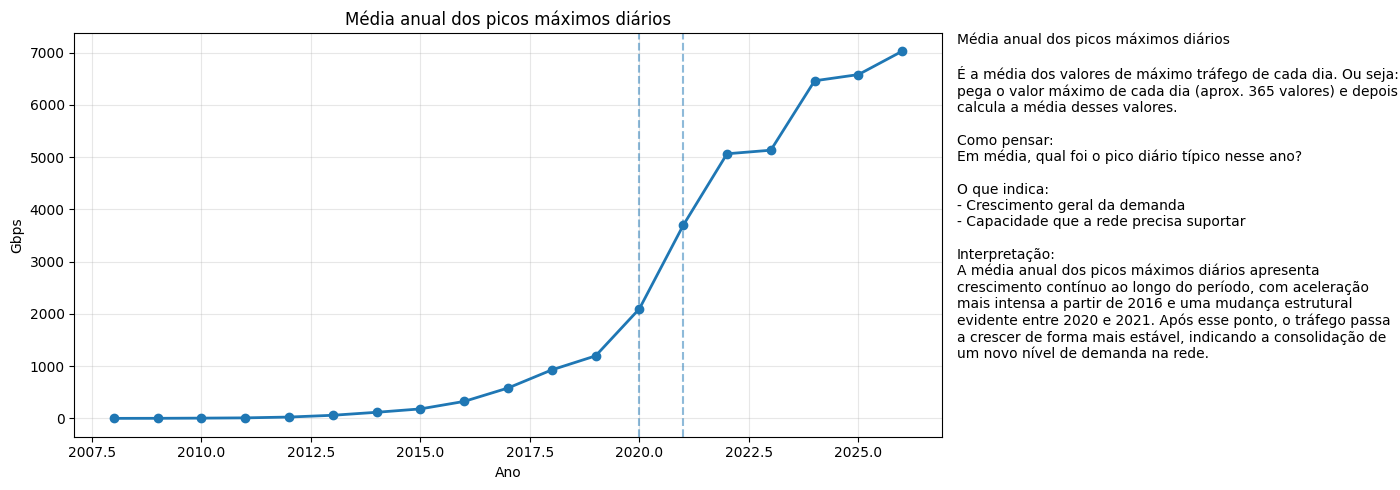

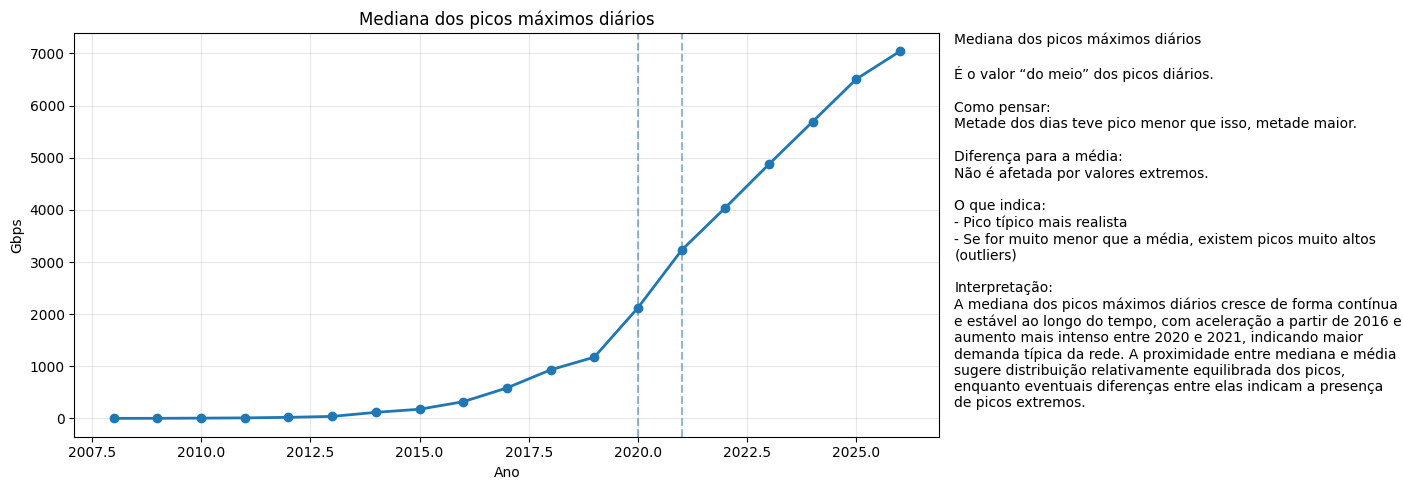

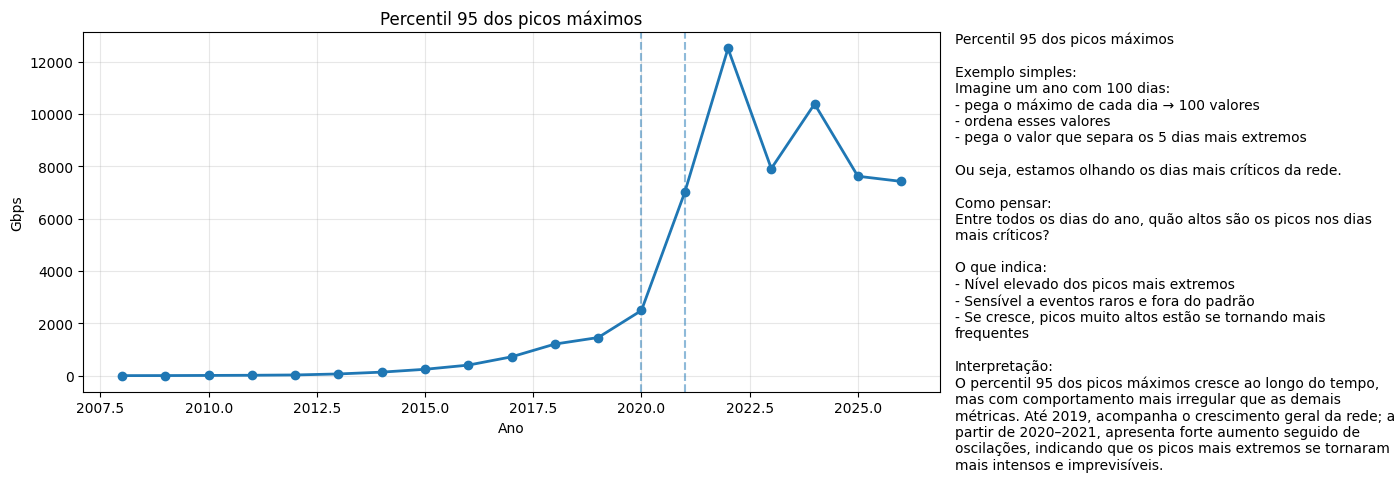

In [140]:
# Variáveis de nível / distribuição dos picos
variaveis_nivel = [
    "media_pico_maximo_gbps",
    "mediana_pico_maximo_gbps",
    "percentil_95_picos_maximos_gbps",
   
    
]

for variavel in variaveis_nivel:
    plot_com_caixa(
        df=resumo_plot,
        coluna=variavel,
        titulo=titulos[variavel],
        texto=textos_variaveis[variavel],
        ylabel=ylabels[variavel]
    )

**Resumo e interpretação integrada**

Considerando que:

Mediana dos picos → comportamento típico

Média dos picos → nível geral (com influência de extremos)

Percentil 95 dos picos → comportamento dos extremos

Leitura integrada

1. Crescimento estrutural da rede
Mediana ↑ continuamente
Média ↑ continuamente

Significa: o uso típico da rede está aumentando de forma consistente

2. Intensificação dos picos
Média cresce mais que a mediana em alguns períodos
P95 cresce muito mais
Significa: Os picos estão ficando mais intensos que o “normal”

3. Aumento da variabilidade (ponto mais importante)
Mediana → suave
P95 → irregular e com saltos

Significa: A rede não só cresceu — ela ficou mais imprevisível

O crescimento do tráfego foi acompanhado por uma mudança na sua distribuição: além do aumento do nível típico de uso, houve intensificação e maior variabilidade dos picos extremos.




A análise conjunta das métricas indica que o crescimento do tráfego não ocorreu apenas no nível médio, mas foi acompanhado por maior variabilidade e intensificação dos picos extremos. Do ponto de vista de planejamento de rede, o percentil 95 dos picos máximos se mostra a métrica mais relevante, pois captura os níveis críticos de demanda que devem ser suportados para garantir a estabilidade do sistema.



## Taxas de crescimento

In [141]:
texto_comparacao_pico_nivel = """
Comparação entre pico e nível de tráfego

O que este gráfico mostra:
Compara a média anual dos picos máximos diários com o nível alto típico de tráfego dentro dos dias.

Como pensar:
A linha dos picos mostra os momentos de maior demanda.
A linha do p95 diário médio mostra um nível alto, mas mais estável, do tráfego diário.

O que observar:
- Se as linhas crescem juntas, o tráfego aumenta de forma proporcional
- Se a linha dos picos se afasta, os picos estão crescendo mais que o nível típico
- Maior distância entre as linhas indica maior variabilidade

Interpretação:
O gráfico ajuda a mostrar se o crescimento da rede é apenas aumento geral de tráfego ou se também há intensificação dos picos.

Resumo:
Quando os picos crescem mais rápido que o nível típico, a rede fica mais sujeita a momentos críticos de alta demanda.
"""

In [146]:
texto_comparacao_pico_nivel = """
Comparação entre pico e nível de tráfego

O que este gráfico mostra:
Compara a média anual dos picos máximos diários com o nível alto típico de tráfego dentro dos dias.

Linha laranaja :Para cada dia pega os 5% maiores valores daquele dia calcula o percentil 95 daquele dia
depois faz a média desses valores ao longo do ano

Linha azul: Pega o valor máximo de cada dia e depois calcula a média anual desses valores

Como pensar:
A linha dos picos mostra os momentos de maior demanda.
A linha do p95 diário médio mostra um nível alto, mas mais estável, do tráfego diário.

O que observar:
- Se as linhas crescem juntas, o tráfego aumenta de forma proporcional
- Se a linha dos picos se afasta, os picos estão crescendo mais que o nível típico
- Maior distância entre as linhas indica maior variabilidade

Interpretação:
O gráfico ajuda a mostrar se o crescimento da rede é apenas aumento geral de tráfego ou se também há intensificação dos picos.

Resumo:
Quando os picos crescem mais rápido que o nível típico, a rede fica mais sujeita a momentos críticos de alta demanda.
"""

In [147]:
import matplotlib.pyplot as plt

def plot_comparacao_com_caixa(
    df,
    coluna_1,
    coluna_2,
    titulo,
    texto,
    label_1,
    label_2,
    ylabel="Gbps",
    xlabel="Ano",
    coluna_x="ano",
    anos_referencia=(2020, 2021),
    figsize=(15, 5)
):
    fig, ax = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [3, 1.2]}
    )

    ax[0].plot(
        df[coluna_x],
        df[coluna_1],
        marker="o",
        linewidth=2,
        label=label_1
    )

    ax[0].plot(
        df[coluna_x],
        df[coluna_2],
        marker="o",
        linewidth=2,
        label=label_2
    )

    for ano in anos_referencia:
        ax[0].axvline(ano, linestyle="--", alpha=0.5)

    ax[0].set_title(titulo)
    ax[0].set_xlabel(xlabel)
    ax[0].set_ylabel(ylabel)
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    ax[1].axis("off")
    ax[1].text(
        0,
        1,
        texto,
        fontsize=10,
        va="top",
        wrap=True
    )

    plt.tight_layout()
    plt.show()

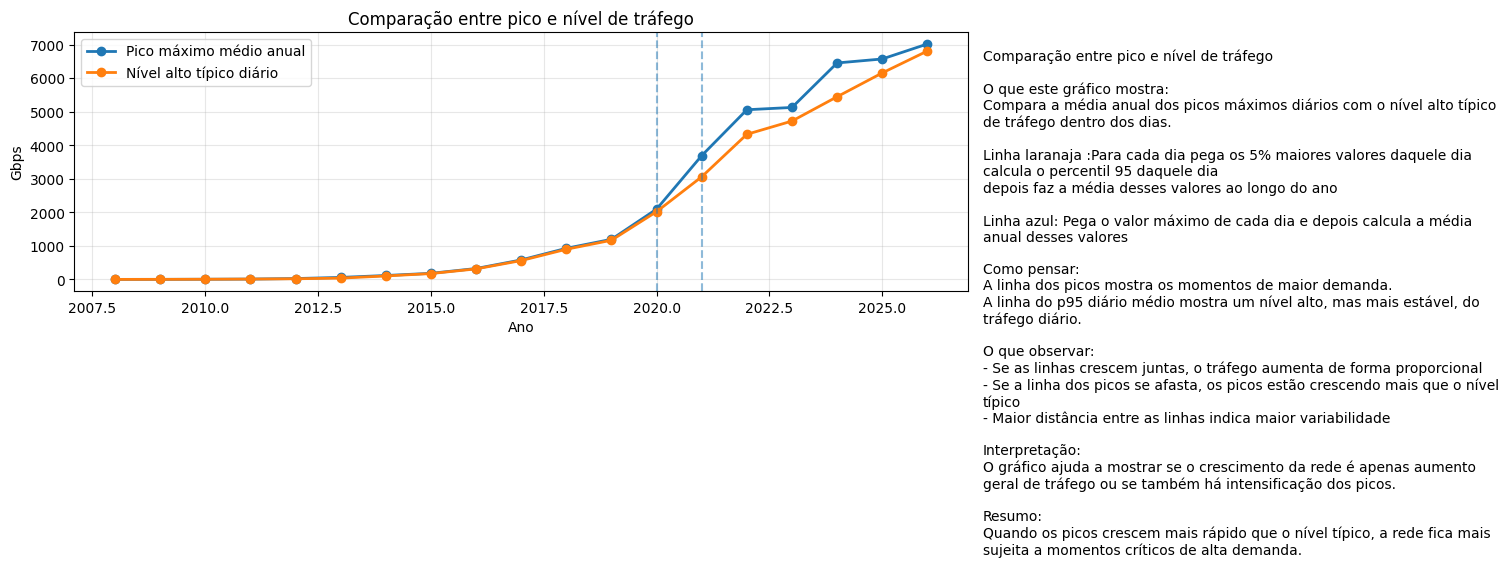

In [148]:
plot_comparacao_com_caixa(
    df=resumo_plot,
    coluna_1="media_pico_maximo_gbps",
    coluna_2="media_percentil_95_diario_gbps",
    titulo="Comparação entre pico e nível de tráfego",
    texto=texto_comparacao_pico_nivel,
    label_1="Pico máximo médio anual",
    label_2="Nível alto típico diário"
)

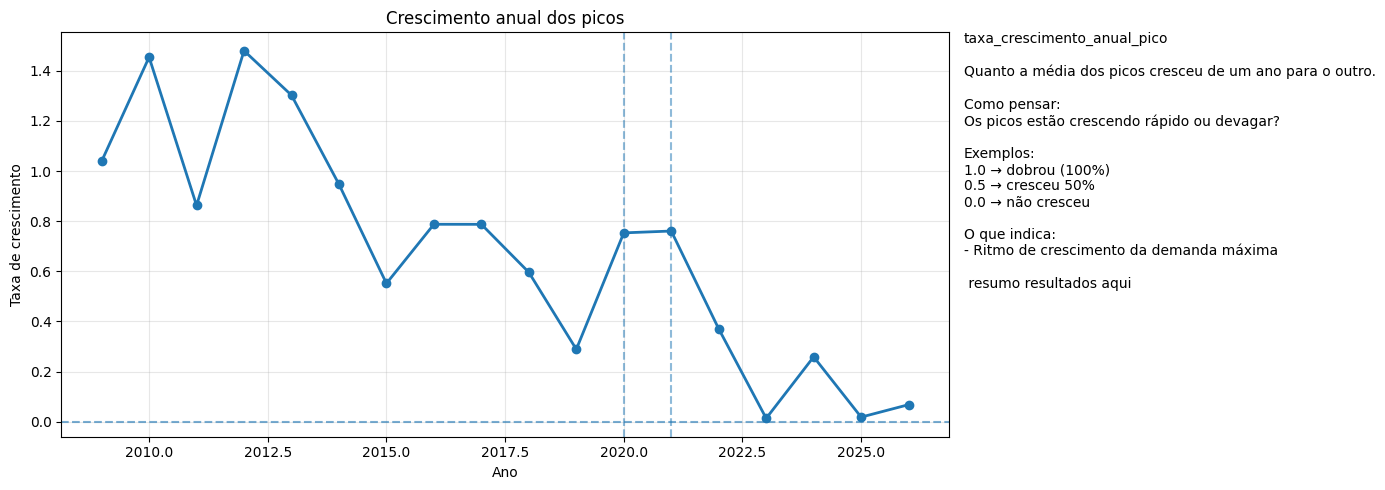

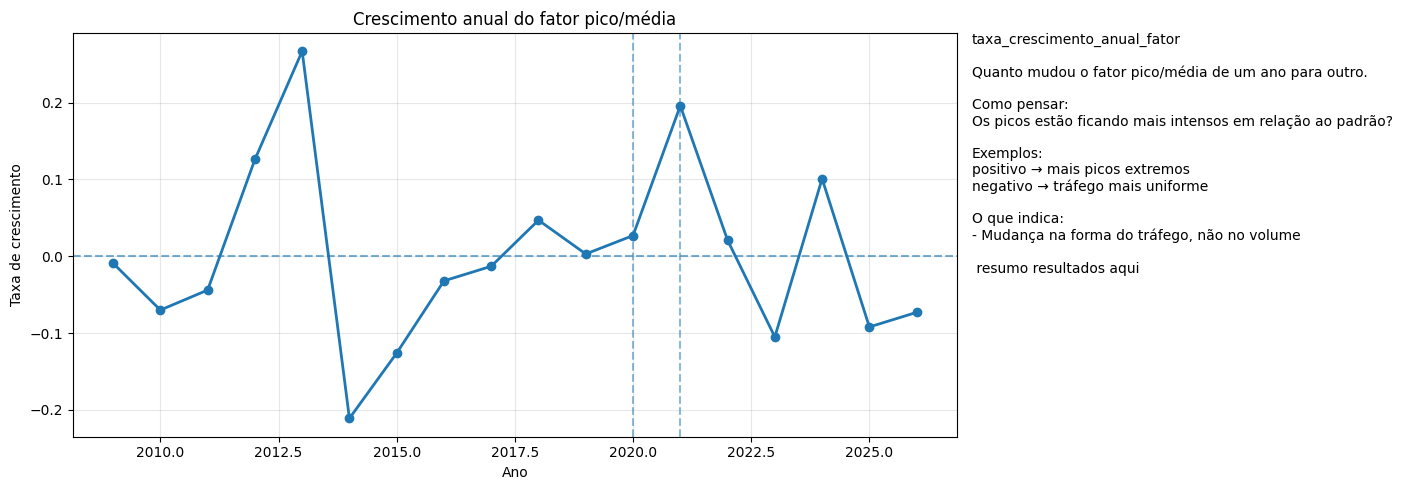

In [ ]:
# Variáveis de taxa de crescimento
variaveis_crescimento = [
    "taxa_crescimento_anual_pico",
    "taxa_crescimento_anual_fator"
]

for variavel in variaveis_crescimento:
    plot_com_caixa(
        df=resumo_plot,
        coluna=variavel,
        titulo=titulos[variavel],
        texto=textos_variaveis[variavel],
        ylabel=ylabels[variavel]
    )

## 26. Evolução intra-anual dos picos diários

In [ ]:
pico_intra_anual = (
    picos_diarios.groupby(["ano", "dia_ano"])["pico_max_gbps"]
    .mean()
    .reset_index()
)

pico_intra_anual.head()

,ano,dia_ano,pico_max_gbps
0,2008,10,0.520317
1,2008,11,0.680078
2,2008,12,0.675091
3,2008,13,0.327326
4,2008,14,0.595106


In [ ]:
for var in variaveis:
    ylabel = "Gbps"
    if "fator" in var:
        ylabel = "Fator"
    if "taxa_crescimento" in var:
        ylabel = "Taxa de crescimento"

    plot_com_caixa(
        df=resumo_plot,
        coluna=var,
        titulo=titulos[var],
        texto=textos_variaveis[var],
        ylabel=ylabel
    )

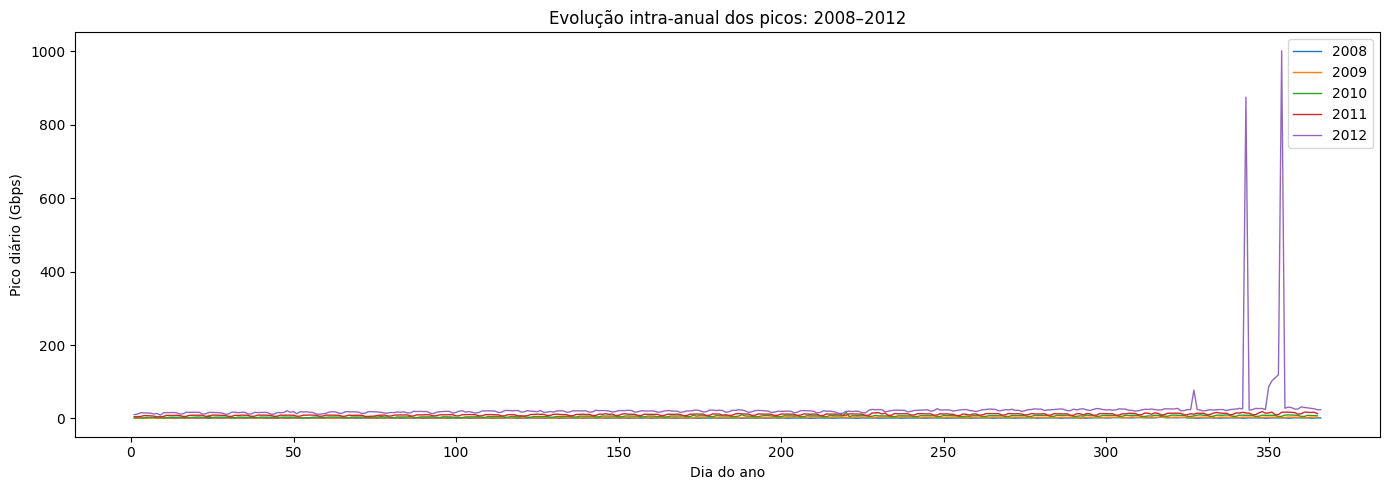

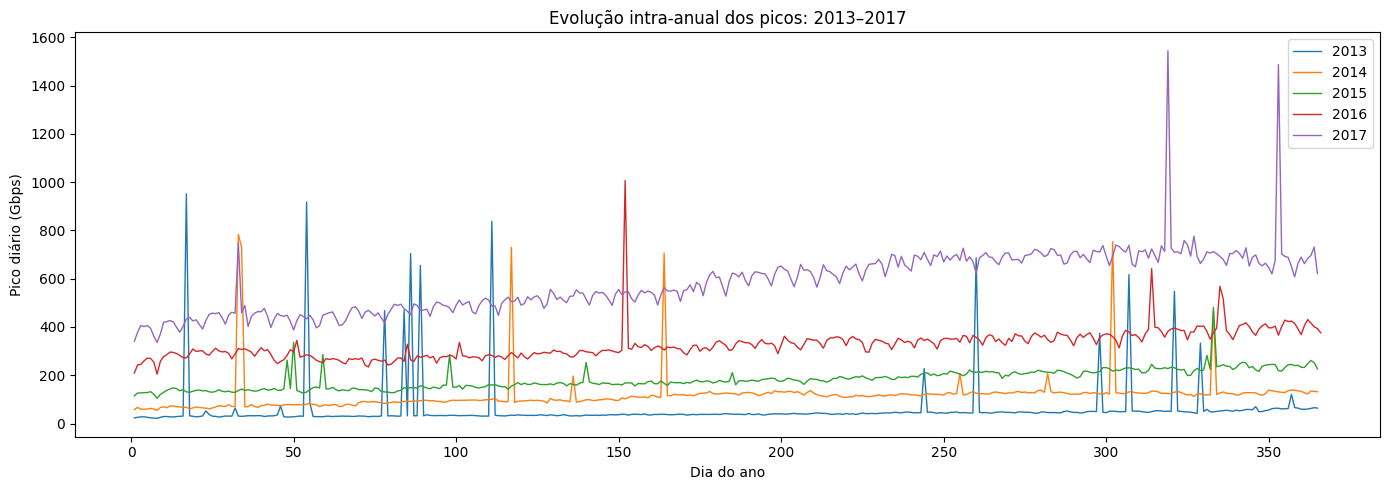

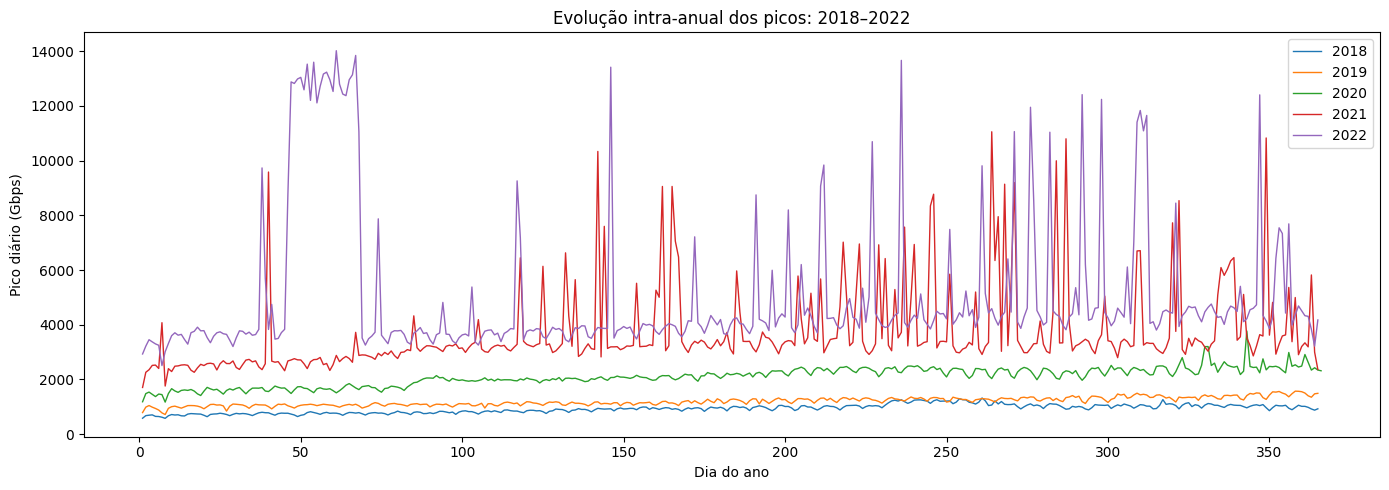

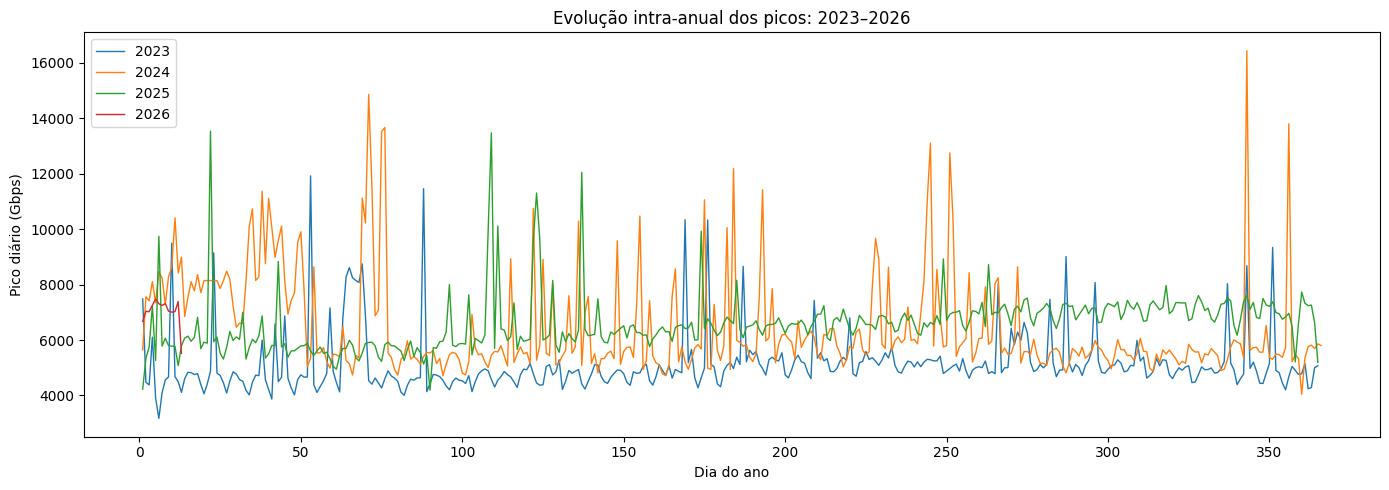

In [ ]:
anos_pico = sorted(pico_intra_anual["ano"].unique())
blocos_pico = [anos_pico[i:i+5] for i in range(0, len(anos_pico), 5)]

for bloco in blocos_pico:
    plt.figure(figsize=(14, 5))

    for ano in bloco:
        df_temp = pico_intra_anual[pico_intra_anual["ano"] == ano]
        plt.plot(df_temp["dia_ano"], df_temp["pico_max_gbps"], label=str(ano), linewidth=1)

    plt.xlabel("Dia do ano")
    plt.ylabel("Pico diário (Gbps)")
    plt.title(f"Evolução intra-anual dos picos: {bloco[0]}–{bloco[-1]}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 27. Picos por dia da semana

Aqui a agregação é feita a partir do **pico diário**, e não da média de todas as observações de 5 em 5 minutos.

In [ ]:
resumo_weekday_picos = (
    picos_diarios.groupby("weekday")
    .agg(
        media_pico_max_gbps=("pico_max_gbps", "mean"),
        media_pico_p95_gbps=("pico_p95_gbps", "mean"),
        media_fator_pico_sobre_media=("fator_pico_sobre_media", "mean")
    )
    .reset_index()
)

resumo_weekday_picos["dia"] = resumo_weekday_picos["weekday"].map(mapa_dias)
resumo_weekday_picos = resumo_weekday_picos.round(3)

resumo_weekday_picos

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(resumo_weekday_picos["weekday"], resumo_weekday_picos["media_pico_max_gbps"], marker="o", label="Pico diário médio")
plt.plot(resumo_weekday_picos["weekday"], resumo_weekday_picos["media_pico_p95_gbps"], marker="o", label="P95 diário médio")
plt.xticks(range(7), [mapa_dias[i] for i in range(7)])
plt.xlabel("Dia da semana")
plt.ylabel("Tráfego (Gbps)")
plt.title("Picos de tráfego por dia da semana")
plt.legend()
plt.tight_layout()
plt.show()

## 28. Picos por dia da semana em blocos de anos

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes = axes.flatten()

periodos = [(2008, 2012), (2013, 2017), (2018, 2022), (2023, 2026)]

for ax, bloco in zip(axes, periodos):
    df_temp = picos_diarios[
        (picos_diarios["ano"] >= bloco[0]) &
        (picos_diarios["ano"] <= bloco[1])
    ]

    media = (
        df_temp.groupby("weekday")["pico_max_gbps"]
        .mean()
        .reset_index(name="media_pico_max_gbps")
    )

    ax.plot(media["weekday"], media["media_pico_max_gbps"], marker="o")
    ax.set_xticks(range(7))
    ax.set_xticklabels([mapa_dias[i] for i in range(7)])
    ax.set_title(f"Picos por dia da semana: {bloco[0]}–{bloco[1]}")
    ax.set_xlabel("Dia da semana")
    ax.set_ylabel("Pico diário médio (Gbps)")
    ax.grid(True)

plt.tight_layout()
plt.show()

## 29. Comparação entre dias úteis e fim de semana para os picos

In [ ]:
comparacao_weekend_picos = (
    picos_diarios.groupby(["ano", "is_weekend"])["pico_max_gbps"]
    .mean()
    .reset_index()
)

comparacao_weekend_picos["grupo"] = comparacao_weekend_picos["is_weekend"].map({
    False: "dias_uteis",
    True: "fim_de_semana"
})

comparacao_weekend_picos_pivot = comparacao_weekend_picos.pivot(
    index="ano",
    columns="grupo",
    values="pico_max_gbps"
)

comparacao_weekend_picos_pivot["razao_fim_semana_sobre_uteis"] = (
    comparacao_weekend_picos_pivot["fim_de_semana"] /
    comparacao_weekend_picos_pivot["dias_uteis"]
)

comparacao_weekend_picos_pivot = comparacao_weekend_picos_pivot.round(3)
comparacao_weekend_picos_pivot

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    comparacao_weekend_picos_pivot.index,
    comparacao_weekend_picos_pivot["razao_fim_semana_sobre_uteis"],
    marker="o"
)
plt.axhline(1.0, linestyle="--")
plt.xlabel("Ano")
plt.ylabel("Fim de semana / dias úteis")
plt.title("Razão entre pico diário médio de fim de semana e dias úteis")
plt.grid(True)
plt.tight_layout()
plt.show()

## 30. Distribuição dos picos diários

In [ ]:
plt.figure(figsize=(12, 5))
plt.hist(picos_diarios["pico_max_gbps"], bins=50)
plt.xlabel("Pico diário (Gbps)")
plt.ylabel("Frequência")
plt.title("Distribuição dos picos diários")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.boxplot(picos_diarios["pico_max_gbps"].dropna(), vert=False)
plt.xlabel("Pico diário (Gbps)")
plt.title("Boxplot dos picos diários")
plt.tight_layout()
plt.show()

## 31. Padrão intra-dia de alta utilização

Além do pico diário, também é possível observar o horário em que a rede tende a operar sob alta carga. Para isso, usa-se o **percentil 95 do tráfego por horário do dia**, agregando todas as observações disponíveis.

In [ ]:
df_picos_intradia = df_filtrado.copy()
df_picos_intradia["hora_decimal"] = (
    df_picos_intradia["datahora"].dt.hour +
    df_picos_intradia["datahora"].dt.minute / 60
)

pico_por_hora = (
    df_picos_intradia.groupby("hora_decimal")["total_gbps"]
    .agg(
        p95_gbps=lambda x: x.quantile(0.95),
        max_gbps="max",
        media_gbps="mean"
    )
    .reset_index()
)

pico_por_hora.head()

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(pico_por_hora["hora_decimal"], pico_por_hora["media_gbps"], label="Média", linewidth=1)
plt.plot(pico_por_hora["hora_decimal"], pico_por_hora["p95_gbps"], label="P95", linewidth=2)
plt.plot(pico_por_hora["hora_decimal"], pico_por_hora["max_gbps"], label="Máximo observado", linewidth=1, alpha=0.8)
plt.xlabel("Hora do dia")
plt.ylabel("Tráfego total (Gbps)")
plt.title("Padrão intra-dia de alta utilização")
plt.xticks(range(0, 25, 2))
plt.legend()
plt.tight_layout()
plt.show()

## 32. Salvando os resumos de picos

In [ ]:
arquivo_resumo_picos_csv = saida_dir / "resumo_picos_diarios.csv"
arquivo_weekday_picos_csv = saida_dir / "resumo_weekday_picos.csv"
arquivo_weekend_picos_csv = saida_dir / "comparacao_weekend_picos.csv"

resumo_picos.to_csv(arquivo_resumo_picos_csv)
resumo_weekday_picos.to_csv(arquivo_weekday_picos_csv, index=False)
comparacao_weekend_picos_pivot.to_csv(arquivo_weekend_picos_csv)

print("Resumo anual de picos salvo em:", arquivo_resumo_picos_csv)
print("Resumo de picos por dia da semana salvo em:", arquivo_weekday_picos_csv)
print("Comparação fim de semana vs dias úteis (picos) salva em:", arquivo_weekend_picos_csv)

# Conclusões preliminares

Com base nos dados filtrados por completude e analisados apenas em termos de tráfego total, é possível observar:

1. crescimento estrutural do tráfego ao longo do tempo;
2. diferenças relevantes entre anos no nível médio de tráfego;
3. utilidade da média diária para reduzir ruído e destacar tendência;
4. presença de variabilidade intra-dia, resumida pelo intervalo de confiança;
5. indícios de variação intra-anual em diferentes períodos;
6. possibilidade de mudança estrutural no padrão semanal, comparando dias úteis e fim de semana.

# Próximos passos

Como continuidade, podem ser desenvolvidas as seguintes análises:

- comparação formal entre anos usando testes ou modelos estatísticos;
- decomposição da série em tendência e sazonalidade;
- análise intra-semana e intra-dia com mais detalhe;
- identificação de pontos de mudança estrutural;
- tratamento de valores suspeitos ou anômalos, se necessário.

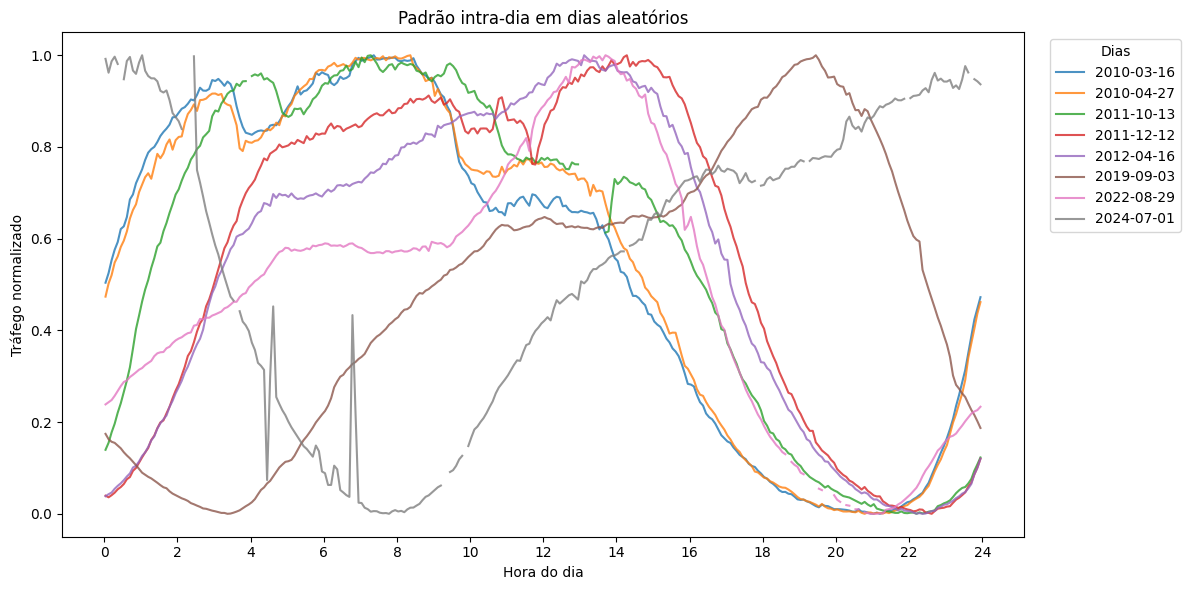

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# cópia da base
df_intradia = df_filtrado.copy()

# criar coluna de data e horário
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["hora_min"] = df_intradia["datahora"].dt.hour * 60 + df_intradia["datahora"].dt.minute

# manter apenas dias completos (288 medições de 5 em 5 min)
contagem_por_dia = df_intradia.groupby("data").size()
dias_completos = contagem_por_dia[contagem_por_dia == 288].index

df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# sortear alguns dias aleatórios
np.random.seed(42)
n_dias = 8
dias_sorteados = np.random.choice(df_intradia["data"].unique(), size=n_dias, replace=False)

df_amostra = df_intradia[df_intradia["data"].isin(dias_sorteados)].copy()

# normalizar cada dia: (x - min) / (max - min)
def normalizar_dia(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_amostra["total_norm"] = df_amostra.groupby("data")["total_gbps"].transform(normalizar_dia)

# eixo x em horas
df_amostra["hora_decimal"] = (
    df_amostra["datahora"].dt.hour +
    df_amostra["datahora"].dt.minute / 60
)

# plot
plt.figure(figsize=(12, 6))

for dia, grupo in df_amostra.groupby("data"):
    plt.plot(grupo["hora_decimal"], grupo["total_norm"], alpha=0.8, label=str(dia))

plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado")
plt.title("Padrão intra-dia em dias aleatórios")
plt.xticks(range(0, 25, 2))
plt.legend(title="Dias", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

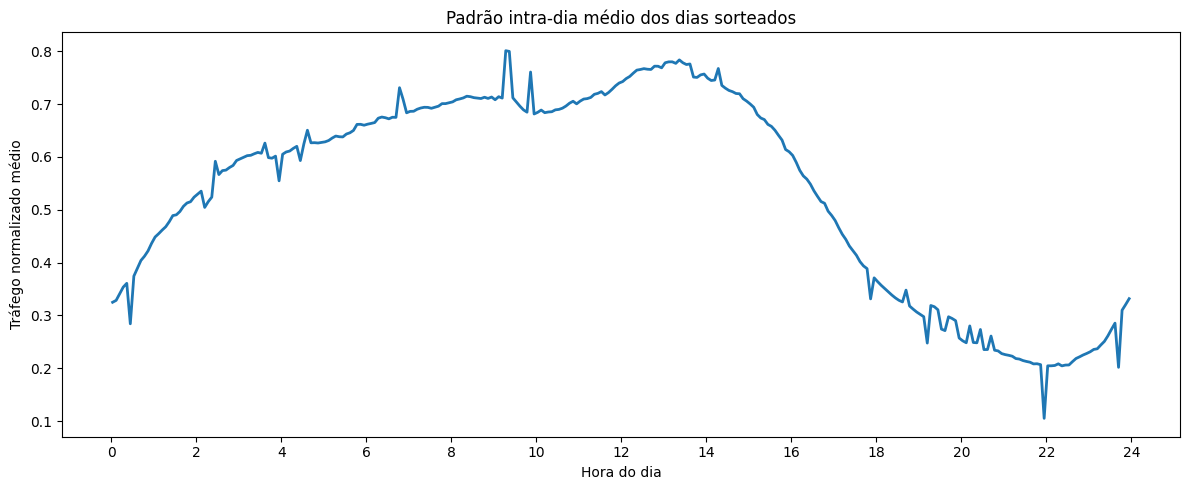

In [ ]:
media_intradia = (
    df_amostra.groupby("hora_decimal")["total_norm"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.plot(media_intradia["hora_decimal"], media_intradia["total_norm"], linewidth=2)
plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado médio")
plt.title("Padrão intra-dia médio dos dias sorteados")
plt.xticks(range(0, 25, 2))
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_intradia = df_filtrado.copy()

# criar variáveis
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["hora_decimal"] = (
    df_intradia["datahora"].dt.hour +
    df_intradia["datahora"].dt.minute / 60
)

# manter apenas dias completos (288 pontos)
contagem = df_intradia.groupby("data").size()
dias_completos = contagem[contagem == 288].index

df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# -------- NORMALIZAÇÃO POR DIA --------
def normalizar(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_intradia["total_norm"] = df_intradia.groupby("data")["total_gbps"].transform(normalizar)

# -------- AGREGAÇÃO INTRA-DIA --------
intradia_stats = (
    df_intradia.groupby("hora_decimal")["total_norm"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# intervalo de confiança 95%
intradia_stats["ci_lower"] = intradia_stats["mean"] - 1.96 * (
    intradia_stats["std"] / np.sqrt(intradia_stats["count"])
)

intradia_stats["ci_upper"] = intradia_stats["mean"] + 1.96 * (
    intradia_stats["std"] / np.sqrt(intradia_stats["count"])
)

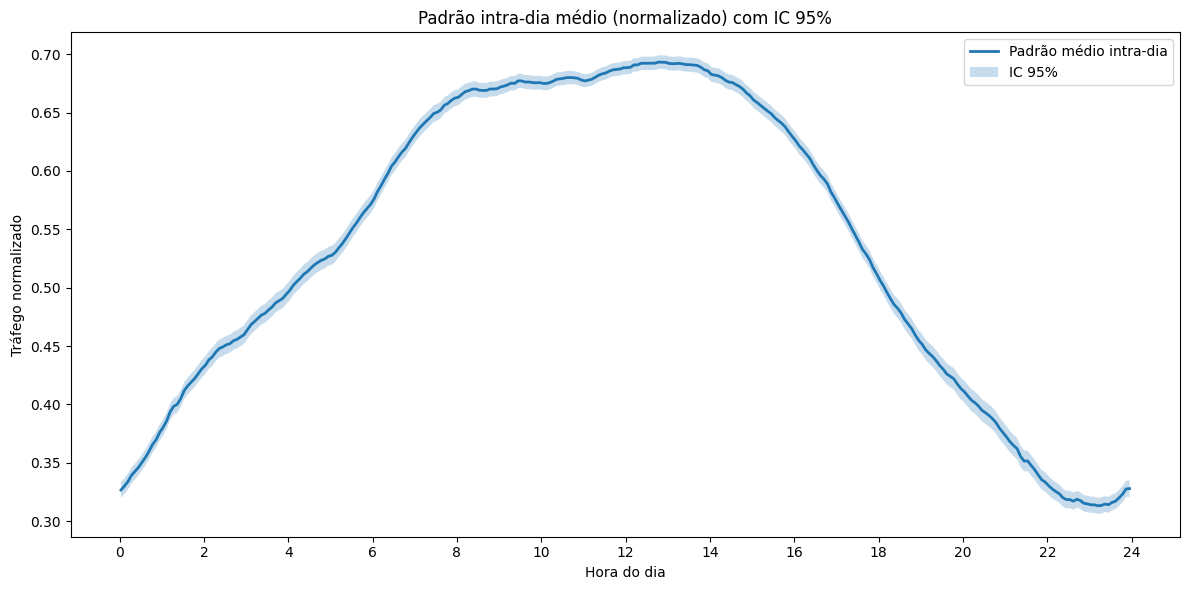

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    intradia_stats["hora_decimal"],
    intradia_stats["mean"],
    label="Padrão médio intra-dia",
    linewidth=2
)

plt.fill_between(
    intradia_stats["hora_decimal"],
    intradia_stats["ci_lower"],
    intradia_stats["ci_upper"],
    alpha=0.25,
    label="IC 95%"
)

plt.xlabel("Hora do dia")
plt.ylabel("Tráfego normalizado")
plt.title("Padrão intra-dia médio (normalizado) com IC 95%")
plt.xticks(range(0, 25, 2))
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_intradia = df_filtrado.copy()

# variáveis auxiliares
df_intradia["data"] = df_intradia["datahora"].dt.date
df_intradia["year"] = df_intradia["datahora"].dt.year
df_intradia["hora_decimal"] = (
    df_intradia["datahora"].dt.hour +
    df_intradia["datahora"].dt.minute / 60
)

# manter apenas dias completos
contagem = df_intradia.groupby("data").size()
dias_completos = contagem[contagem == 288].index
df_intradia = df_intradia[df_intradia["data"].isin(dias_completos)].copy()

# normalização por dia
def normalizar(x):
    xmin = x.min()
    xmax = x.max()
    if xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

df_intradia["total_norm"] = df_intradia.groupby("data")["total_gbps"].transform(normalizar)

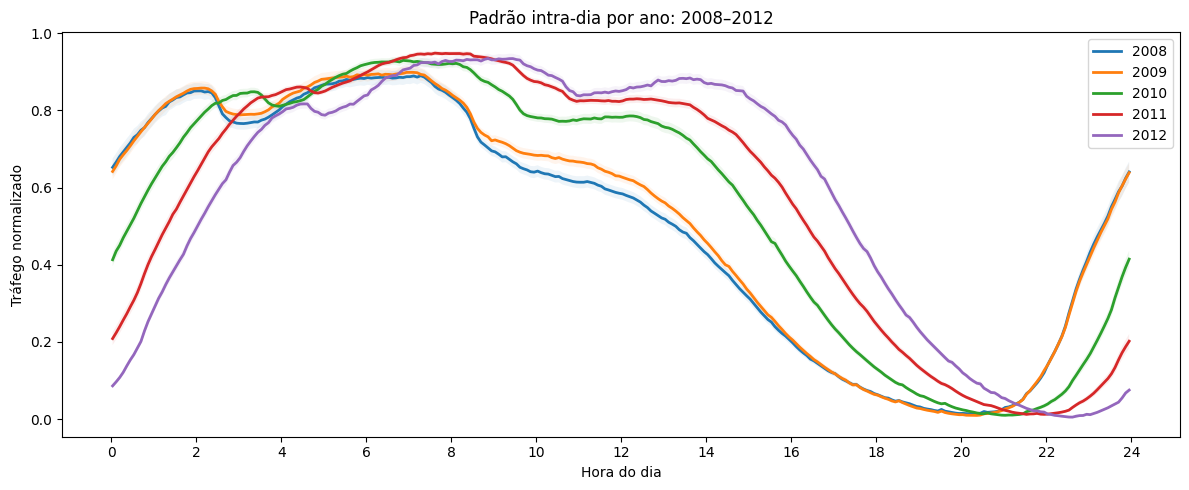

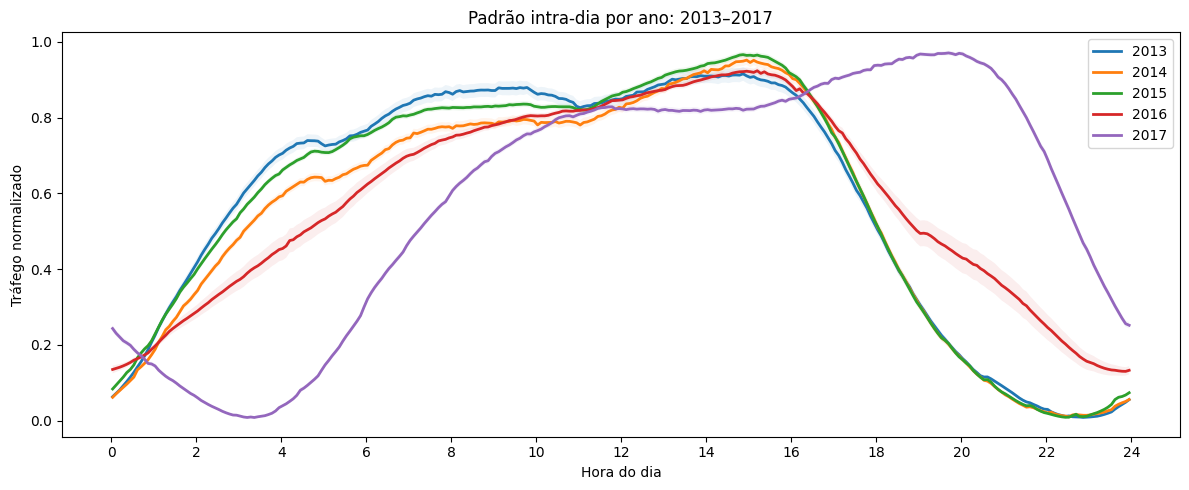

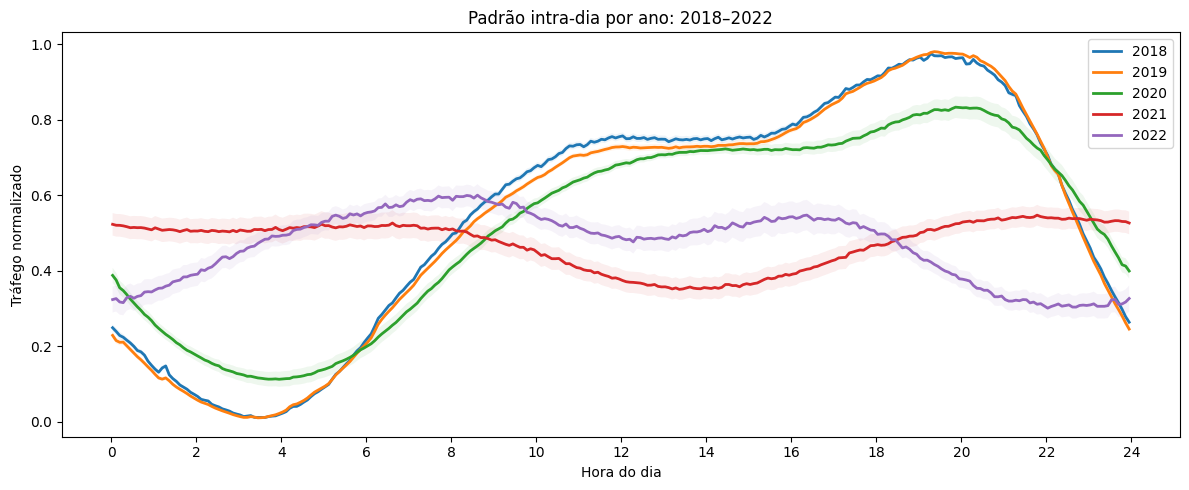

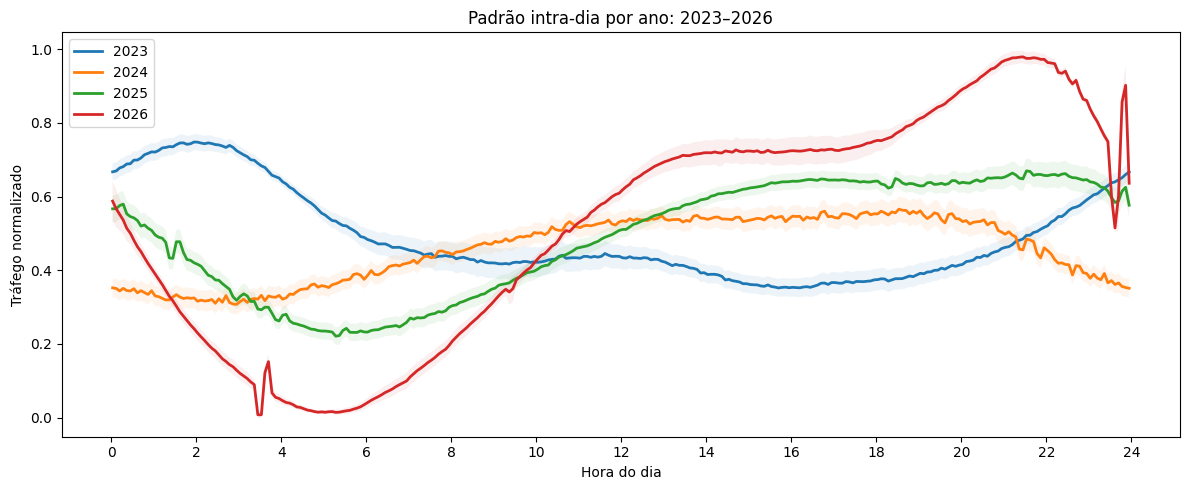

In [ ]:
anos = sorted(df_intradia["year"].unique())


blocos = [anos[i:i+5] for i in range(0, len(anos), 5)]

for bloco in blocos:
    plt.figure(figsize=(12, 5))

    for ano in bloco:
        df_ano = df_intradia[df_intradia["year"] == ano]

        stats = (
            df_ano.groupby("hora_decimal")["total_norm"]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        # IC
        stats["ci_lower"] = stats["mean"] - 1.96 * (stats["std"] / np.sqrt(stats["count"]))
        stats["ci_upper"] = stats["mean"] + 1.96 * (stats["std"] / np.sqrt(stats["count"]))

        # linha principal
        plt.plot(
            stats["hora_decimal"],
            stats["mean"],
            label=str(ano),
            linewidth=2
        )

        # IC (opcional mais leve)
        plt.fill_between(
            stats["hora_decimal"],
            stats["ci_lower"],
            stats["ci_upper"],
            alpha=0.08
        )

    plt.xlabel("Hora do dia")
    plt.ylabel("Tráfego normalizado")
    plt.title(f"Padrão intra-dia por ano: {bloco[0]}–{bloco[-1]}")
    plt.xticks(range(0, 25, 2))
    plt.legend()
    plt.tight_layout()
    plt.show()

# Interpretação dos padrões intra-diários

## Evolução do comportamento ao longo do tempo

A análise dos perfis intra-diários revela uma transformação significativa no comportamento do tráfego agregado do IX ao longo dos anos.

### 2008–2012: padrão concentrado e antecipado

Nos anos iniciais, observa-se:

- pico de tráfego nas primeiras horas do dia (aproximadamente entre 6h e 8h);
- queda progressiva ao longo do dia;
- valores mínimos durante a noite.

Esse comportamento é consistente com um padrão de uso predominantemente corporativo, no qual o tráfego está associado a atividades em horário comercial.

---

### 2013–2017: período de transição

Nesse intervalo, verifica-se:

- deslocamento gradual do pico para o meio do dia;
- aumento da largura da curva de tráfego;
- redução da diferença entre períodos de alta e baixa utilização.

Esse padrão sugere uma transição no perfil de uso da rede, possivelmente associada à expansão do acesso residencial e ao aumento do consumo de conteúdo online.

---

### 2018–2022: predominância de consumo digital

A partir de 2018, observa-se uma mudança mais acentuada:

- pico de tráfego deslocado para o período noturno (aproximadamente entre 18h e 21h);
- curva mais "achatada", indicando uso mais distribuído ao longo do dia;
- menor variação relativa entre diferentes horários.

Esse comportamento é compatível com o crescimento de aplicações como streaming, redes sociais e uso intensivo da internet em dispositivos móveis.

---

### 2023–2026: uso contínuo da rede

Nos anos mais recentes:

- o tráfego apresenta maior uniformidade ao longo do dia;
- a diferença entre períodos de pico e vale é reduzida;
- o sistema opera próximo de níveis elevados durante a maior parte do tempo.

Esse padrão indica que a internet passou a ser utilizada como infraestrutura contínua, e não mais apenas em horários específicos.

---

## Mudança estrutural no perfil de uso

De forma geral, os resultados evidenciam uma mudança estrutural no comportamento da rede:

- inicialmente dominada por uso corporativo;
- posteriormente caracterizada por uma fase de transição;
- e, por fim, marcada por consumo massivo e contínuo de conteúdo digital.

Essa transformação reflete mudanças tecnológicas e sociais, incluindo maior penetração da internet, crescimento do consumo de mídia online e alterações nos hábitos dos usuários.

---

## Estabilidade do formato intra-diário

Apesar da evolução observada, nota-se que:

- o padrão intra-diário mantém uma forma consistente;
- o que se altera ao longo do tempo é principalmente o nível (escala) e o posicionamento do pico.

Isso sugere que o sistema apresenta:

- invariância de forma (shape);
- crescimento de escala (level).

---

## Qualidade dos dados e anomalias

Durante a análise, foram identificados alguns comportamentos atípicos, como:

- curvas com quedas abruptas próximas de zero;
- padrões inconsistentes em determinados anos (por exemplo, 2026).

Esses casos indicam possíveis problemas de medição ou dados incompletos, reforçando a importância da etapa de validação e filtragem da base antes da análise.

---

## Conclusão

A análise intra-diária mostra que:

- o comportamento do tráfego evoluiu significativamente ao longo dos anos;
- o pico de utilização foi deslocado para períodos mais tardios;
- o uso da rede tornou-se mais contínuo e distribuído ao longo do dia.

Esses resultados são consistentes com a transformação da internet em uma infraestrutura essencial para múltiplos tipos de uso, incluindo entretenimento, comunicação e trabalho remoto.

## Padrão intra-dia — principais achados

- 2008–2012: pico pela manhã → uso mais corporativo  
- 2013–2017: transição → uso mais distribuído  
- 2018–2022: pico à noite → consumo digital (streaming, mobile)  
- 2023+: uso quase contínuo ao longo do dia  

👉 Mudança estrutural:
- de uso concentrado → uso massivo e distribuído  

👉 Padrão diário é estável (forma), mas cresce em escala  

⚠️ Há indícios de dados anômalos em alguns anos (ex: 2026)



A internet deixou de ter horário de uso — ela virou infraestrutura contínua.”